In [1]:
import math
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np


class SignSegmenter:
    """Unified segmentation engine for Red, Blue, and Yellow road signs."""

    def __init__(self):
        # HSV Color Threshold Ranges
        self.red_lower1 = np.array([0, 80, 60])
        self.red_upper1 = np.array([10, 255, 255])
        self.red_lower2 = np.array([168, 80, 60])
        self.red_upper2 = np.array([179, 255, 255])

        self.blue_lower = np.array([100, 120, 40])
        self.blue_upper = np.array([135, 255, 255])

        self.yellow_lower = np.array([10, 77, 77])
        self.yellow_upper = np.array([34, 255, 255])

    def _enhance_illumination(
        self, rgb_img: np.ndarray, clip_limit: float = 3.0
    ) -> np.ndarray:
        """Applies CLAHE to the Value channel in HSV space for lighting robustness."""
        blurred = cv2.GaussianBlur(rgb_img, (3, 3), 0)
        hsv = cv2.cvtColor(blurred, cv2.COLOR_RGB2HSV)
        h, s, v = cv2.split(hsv)

        clahe = cv2.createCLAHE(
            clipLimit=clip_limit, tileGridSize=(5, 5)
        )
        v_enhanced = clahe.apply(v)

        return cv2.merge((h, s, v_enhanced))

    def _refine_and_alpha_blend(
        self, rgb_img: np.ndarray, binary_mask: np.ndarray
    ) -> tuple[np.ndarray, np.ndarray]:
        """Filters out small noise contours and applies feathered transparency blending."""
        refined_mask = np.zeros_like(binary_mask)
        contours, _ = cv2.findContours(
            binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )

        if contours:
            # Keep the largest valid contour
            valid_contours = [
                c for c in contours if cv2.contourArea(c) > 300
            ]
            if valid_contours:
                largest_blob = max(valid_contours, key=cv2.contourArea)
                cv2.drawContours(
                    refined_mask,
                    [largest_blob],
                    -1,
                    255,
                    thickness=cv2.FILLED,
                )

        # Dynamic feathering kernel based on image dimensions
        h, w = rgb_img.shape[:2]
        ksize = math.floor(((h + w) // 2) * 0.05)
        if ksize % 2 == 0:
            ksize += 1
        ksize = max(3, ksize)

        soft_mask = cv2.GaussianBlur(refined_mask, (ksize, ksize), 0)
        alpha = soft_mask.astype(float) / 255.0
        alpha_3d = cv2.merge([alpha, alpha, alpha])

        isolated_roi = (rgb_img.astype(float) * alpha_3d).astype(np.uint8)
        return isolated_roi, refined_mask

    def isolate_red(self, rgb_img: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        """Segments red traffic signs using dual-range HSV masking."""
        hsv = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2HSV)

        # Combine wrap-around red hue bounds
        mask1 = cv2.inRange(hsv, self.red_lower1, self.red_upper1)
        mask2 = cv2.inRange(hsv, self.red_lower2, self.red_upper2)
        raw_mask = cv2.bitwise_or(mask1, mask2)

        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        cleaned_mask = cv2.morphologyEx(
            raw_mask, cv2.MORPH_OPEN, kernel
        )
        cleaned_mask = cv2.morphologyEx(
            cleaned_mask, cv2.MORPH_CLOSE, kernel
        )

        return self._refine_and_alpha_blend(rgb_img, cleaned_mask)

    def isolate_blue(
        self, rgb_img: np.ndarray
    ) -> tuple[np.ndarray, np.ndarray]:
        """Segments blue traffic signs with CLAHE enhancement."""
        enhanced_hsv = self._enhance_illumination(rgb_img, clip_limit=3.0)
        raw_mask = cv2.inRange(
            enhanced_hsv, self.blue_lower, self.blue_upper
        )

        kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))

        opened = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, kernel_open)
        closed = cv2.morphologyEx(
            opened, cv2.MORPH_CLOSE, kernel_close
        )

        return self._refine_and_alpha_blend(rgb_img, closed)

    def isolate_yellow(
        self, rgb_img: np.ndarray
    ) -> tuple[np.ndarray, np.ndarray]:
        """Segments yellow traffic signs with adaptive morphological kernels."""
        enhanced_hsv = self._enhance_illumination(rgb_img, clip_limit=5.0)
        raw_mask = cv2.inRange(
            enhanced_hsv, self.yellow_lower, self.yellow_upper
        )

        kw = max(3, math.ceil(rgb_img.shape[1] * 0.02))
        kh = max(3, math.ceil(rgb_img.shape[0] * 0.02))
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kw, kh))

        closed = cv2.morphologyEx(raw_mask, cv2.MORPH_CLOSE, kernel)
        opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel)

        return self._refine_and_alpha_blend(rgb_img, opened)


def load_dataset(folder_path: str | Path) -> list[tuple[Path, np.ndarray]]:
    """Loads all valid images from a directory as RGB numpy arrays."""
    dir_path = Path(folder_path)
    valid_exts = {".jpg", ".jpeg", ".png", ".bmp"}
    images = []

    if not dir_path.exists():
        print(f"Directory not found: {dir_path}")
        return images

    for file_path in sorted(dir_path.rglob("*")):
        if file_path.is_file() and file_path.suffix.lower() in valid_exts:
            bgr_img = cv2.imread(str(file_path))
            if bgr_img is not None:
                rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
                images.append((file_path, rgb_img))
            else:
                print(f"Warning: Failed to load {file_path.name}")

    return images


def run_pipeline(directory: str | Path, color_mode: str = "red"):
    """
    Processes all images in target folder using selected color pipeline.
    Modes available: 'red', 'blue', 'yellow'
    """
    dataset = load_dataset(directory)
    print(
        f"Processing {len(dataset)} images from '{directory}' using [{color_mode.upper()}] mode..."
    )

    segmenter = SignSegmenter()
    pipeline_map = {
        "red": segmenter.isolate_red,
        "blue": segmenter.isolate_blue,
        "yellow": segmenter.isolate_yellow,
    }

    if color_mode.lower() not in pipeline_map:
        raise ValueError(
            f"Invalid mode '{color_mode}'. Choose from: 'red', 'blue', 'yellow'."
        )

    segment_fn = pipeline_map[color_mode.lower()]

    for path, original_rgb in dataset:
        # Standardize size for processing consistency
        resized_rgb = cv2.resize(original_rgb, (300, 300))

        # Extract isolated ROI and Mask
        extracted_roi, mask = segment_fn(resized_rgb)

        # Example usage: display first result or process further
        print(f"Successfully processed: {path.name}")


if __name__ == "__main__":
    # Example execution across target directories
    # Update paths according to your local environment
    base_dir = Path(r"C:\Users\jonat\OneDrive\Desktop\degree\y2s2\mini project\UCCC2513_Trimester_202506_P16_Group4_Traffic_Sign_Segmentation_and_Classification\Coding Environment\dataset\Demo\Inputs - Original")

    # Run for Red Signs
    run_pipeline(base_dir / "Red signs", color_mode="red")

    # Run for Blue Signs
    # run_pipeline(base_dir / "Blue signs", color_mode="blue")

    # Run for Yellow Signs
    # run_pipeline(base_dir / "Yellow Signs", color_mode="yellow")

Processing 28 images from 'C:\Users\jonat\OneDrive\Desktop\degree\y2s2\mini project\UCCC2513_Trimester_202506_P16_Group4_Traffic_Sign_Segmentation_and_Classification\Coding Environment\dataset\Demo\Inputs - Original\Red signs' using [RED] mode...
Successfully processed: 000_1_0002.png
Successfully processed: 000_1_0013.png
Successfully processed: 000_1_0018.png
Successfully processed: 000_1_0034.png
Successfully processed: 001_0004.png
Successfully processed: 001_1_0009.png
Successfully processed: 002_0036.png
Successfully processed: 002_1_0010.png
Successfully processed: 003_1_0034.png
Successfully processed: 004_1_0020.png
Successfully processed: 005_0030.png
Successfully processed: 005_1_0027.png
Successfully processed: 007_1_0006.png
Successfully processed: 008_1_0008_1_j.png
Successfully processed: 010_1_0013.png
Successfully processed: 011_0029.png
Successfully processed: 011_1_0019.png
Successfully processed: 012_1_0015.png
Successfully processed: 013_0013.png
Successfully proce

Loaded 28 images for processing.


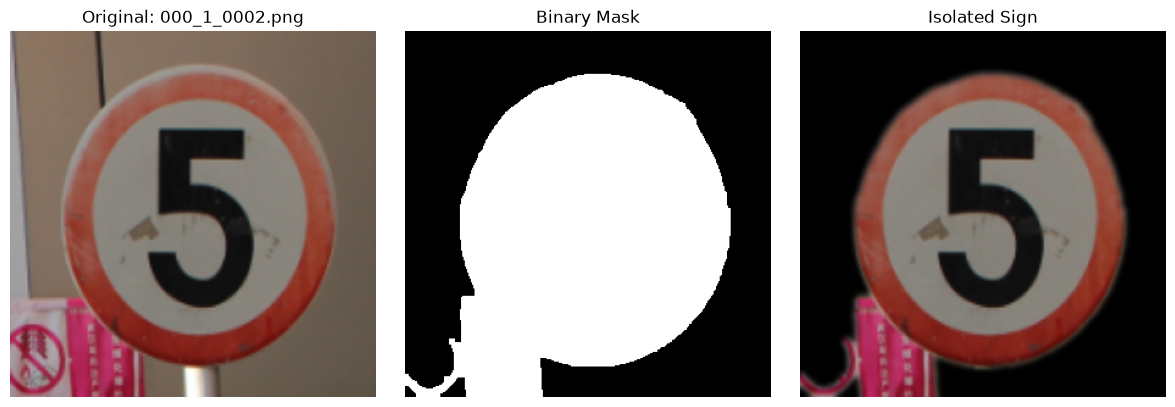

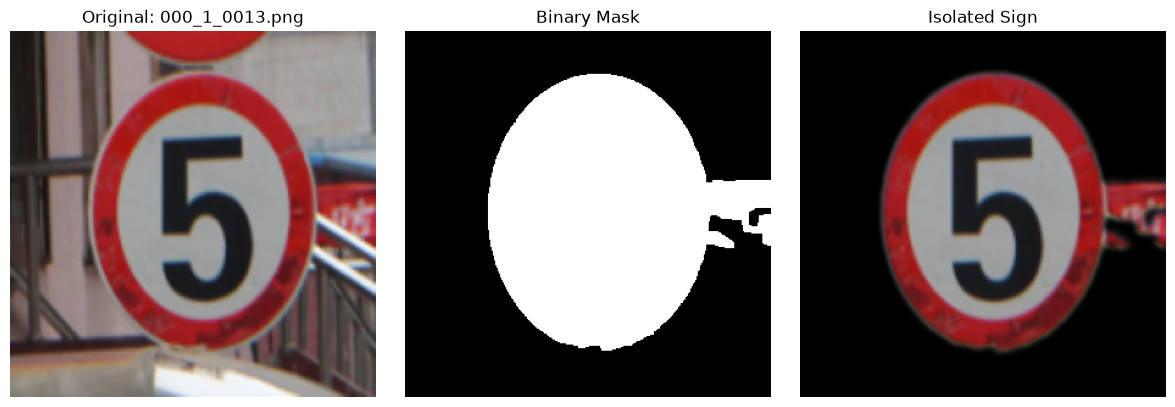

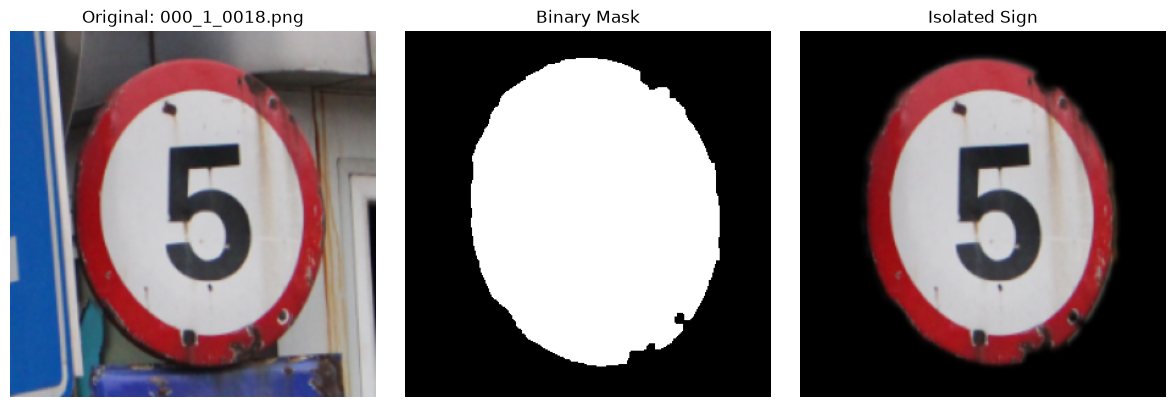

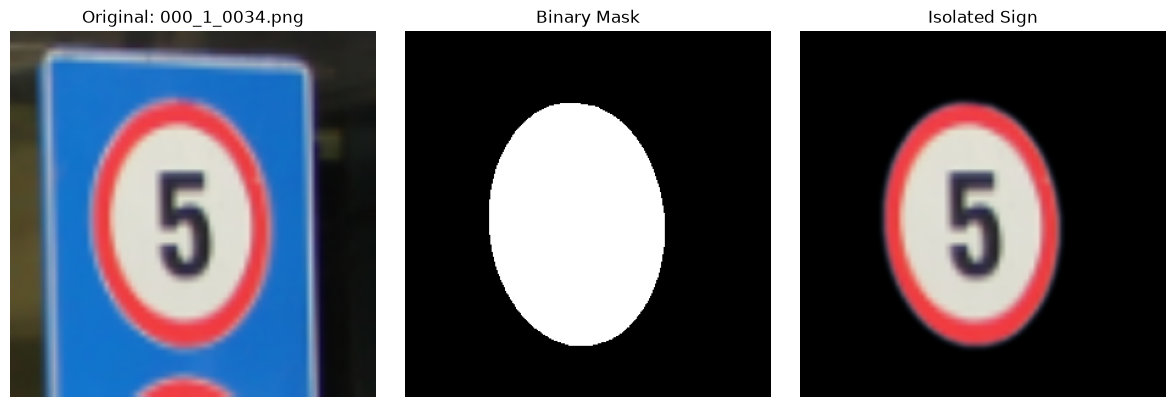

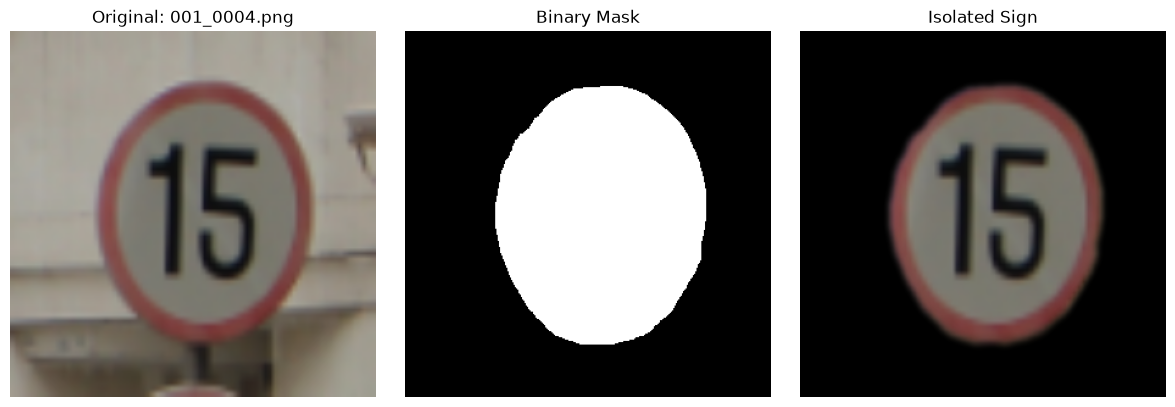

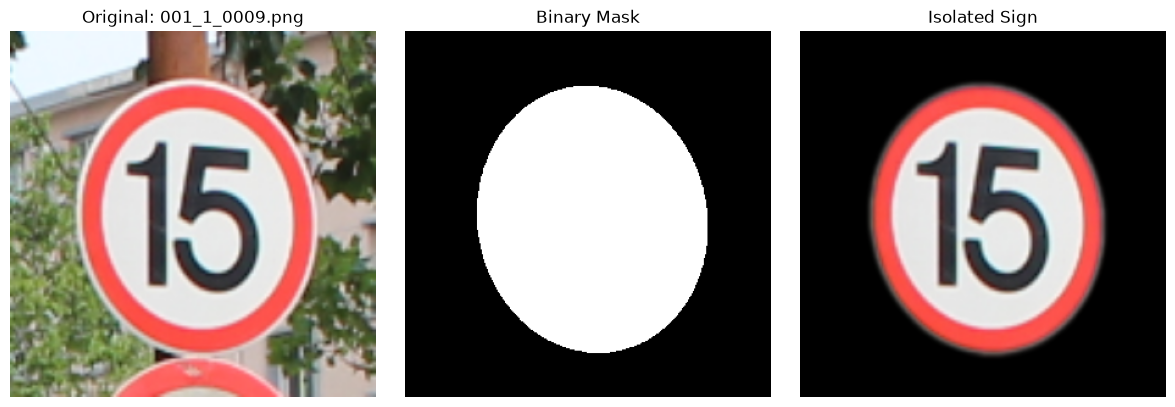

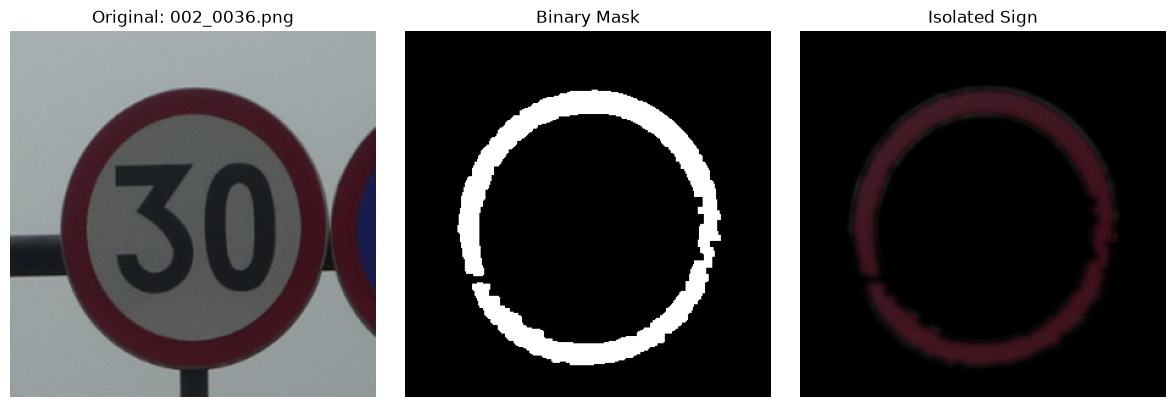

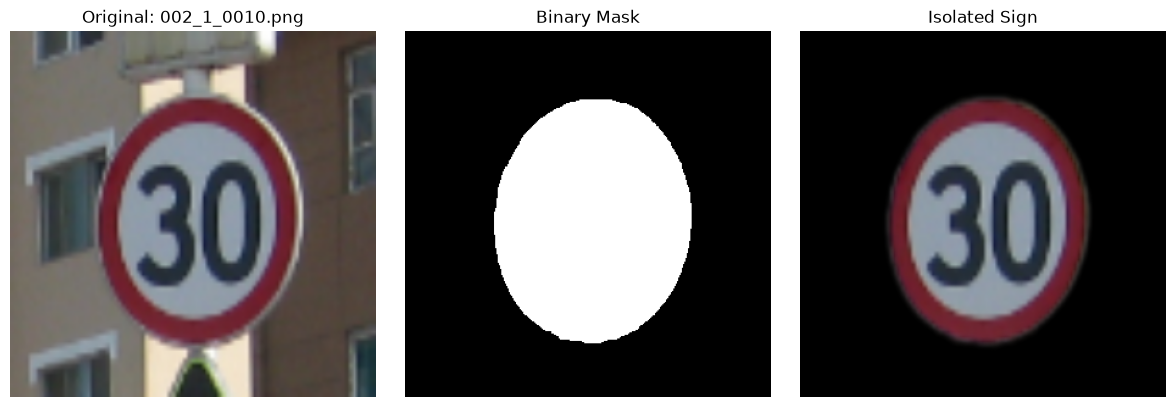

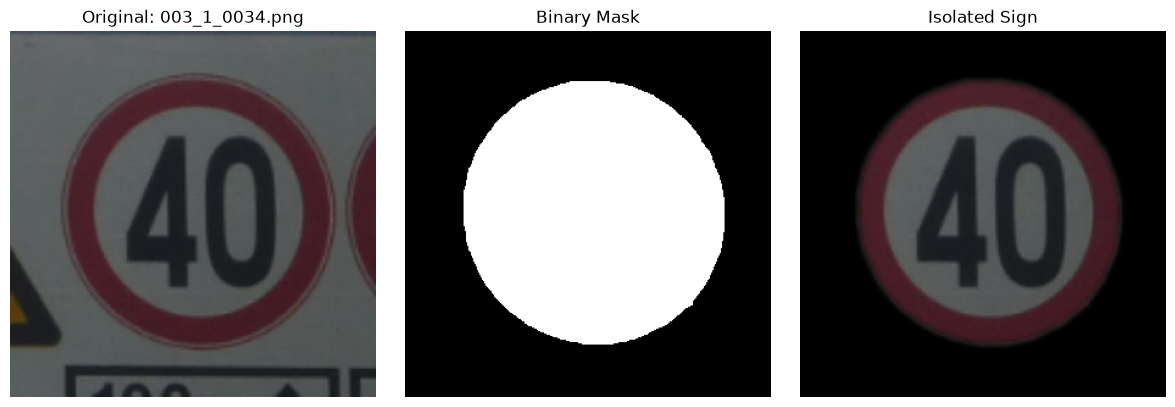

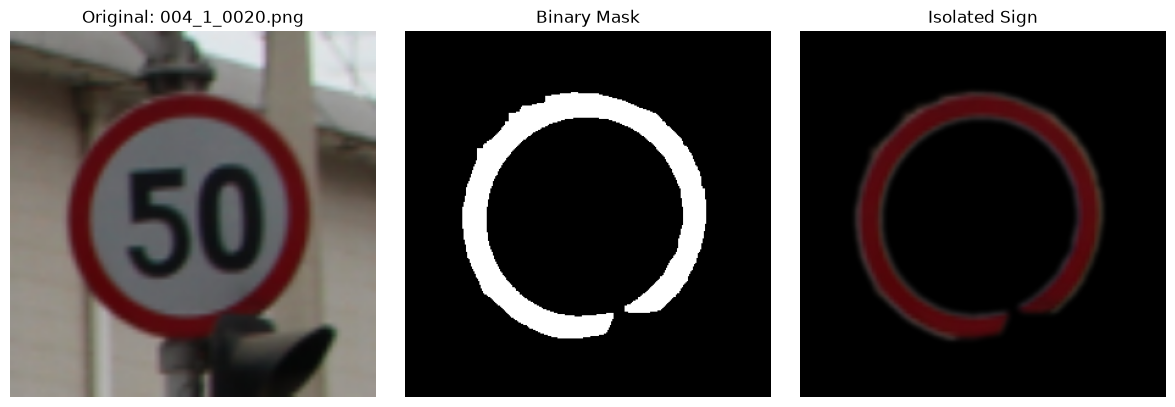

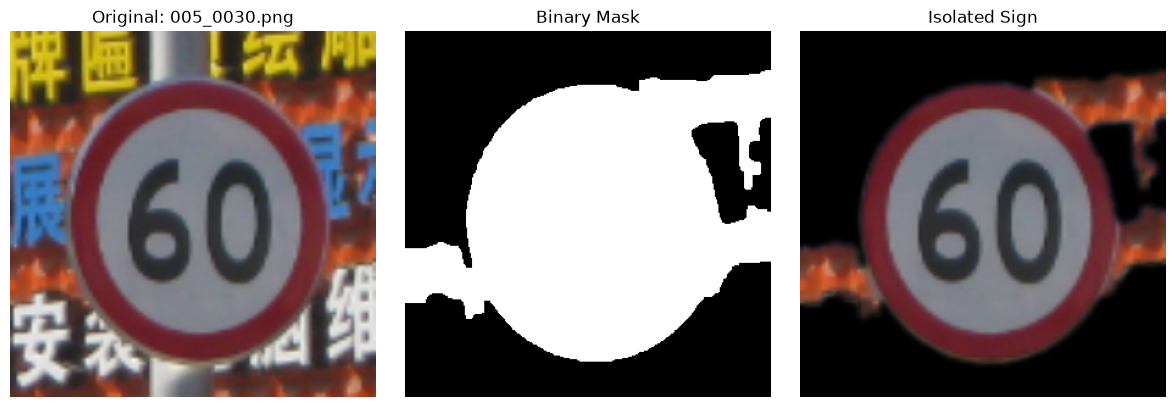

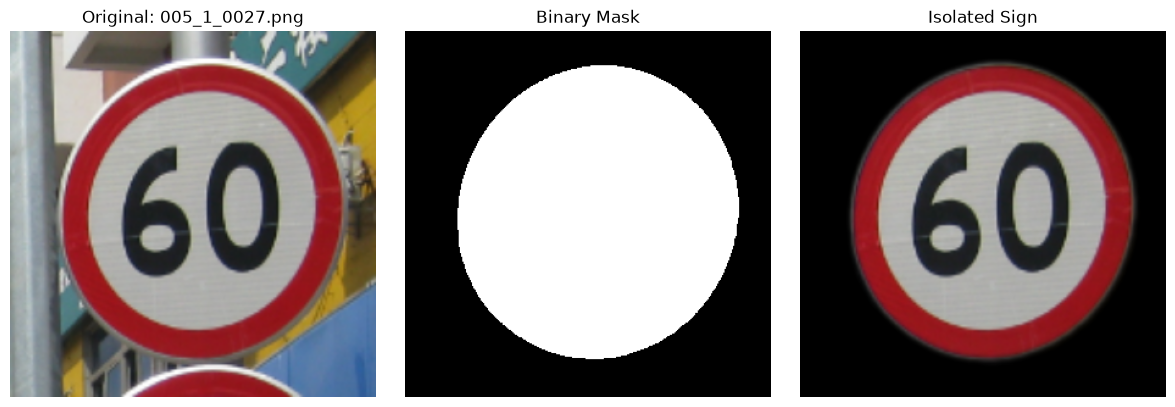

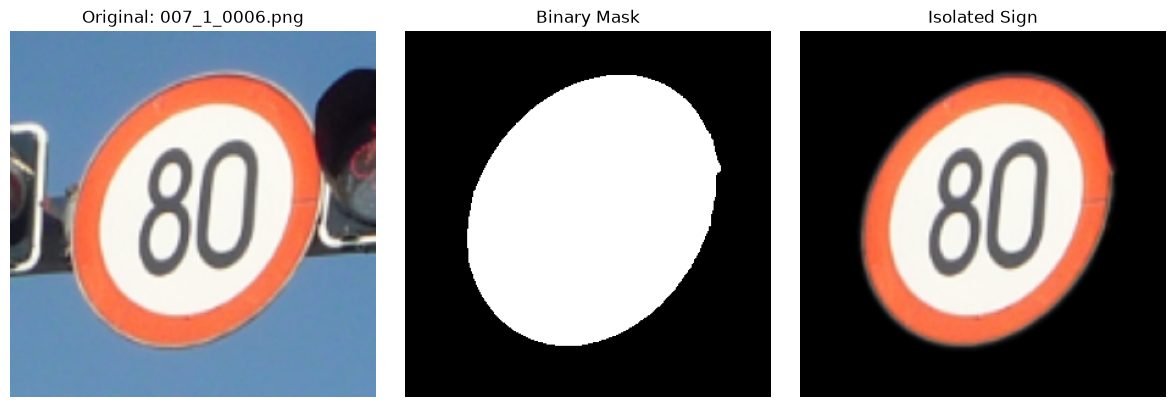

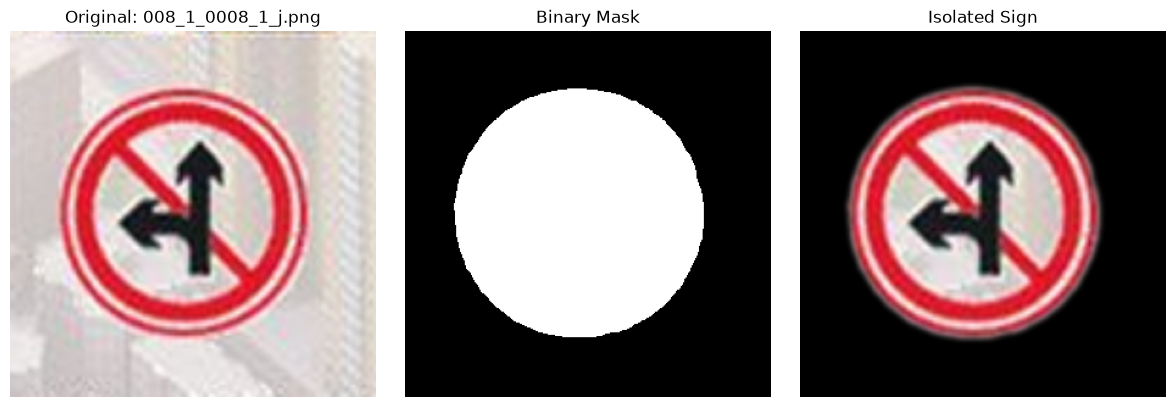

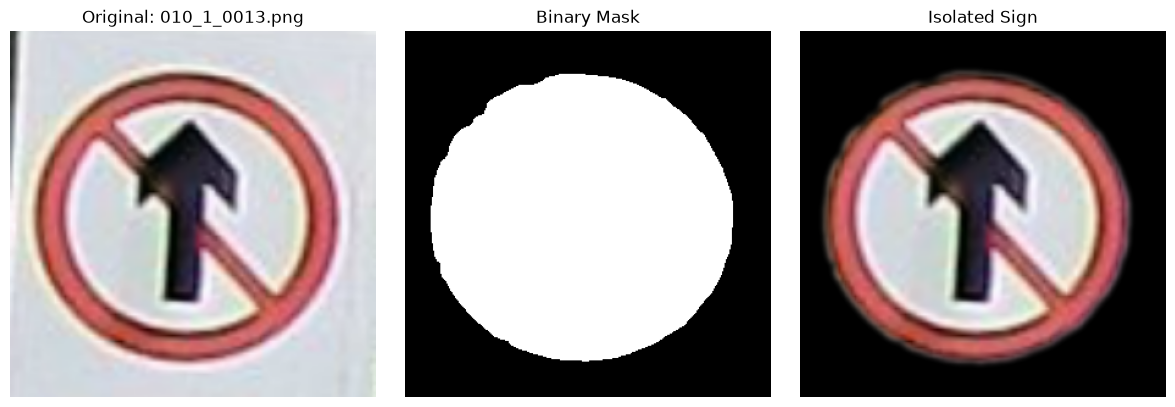

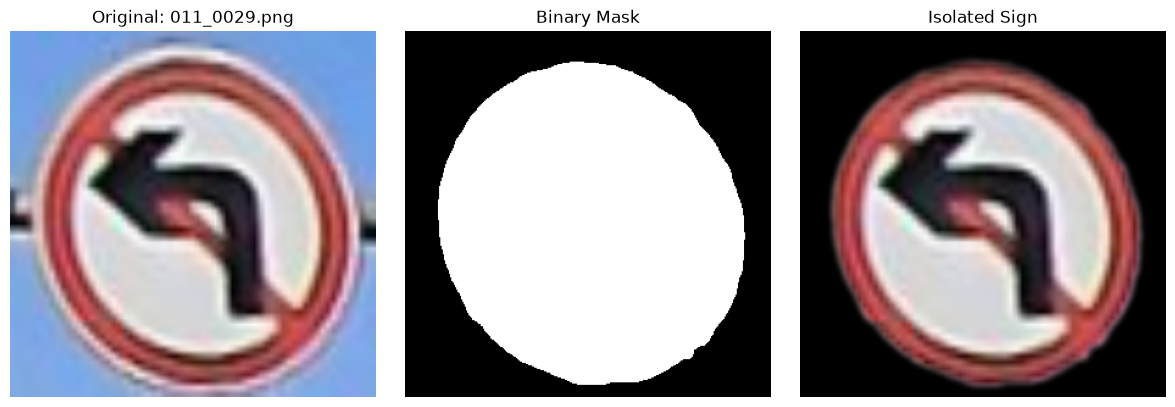

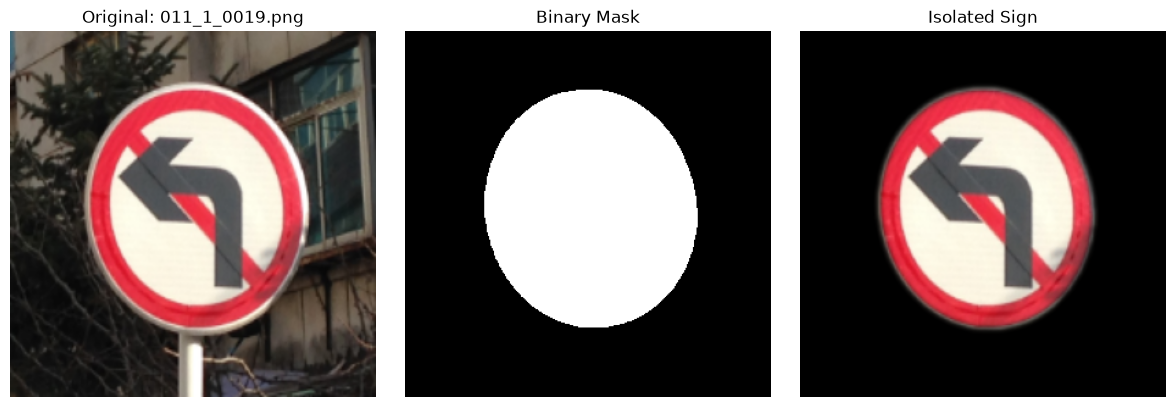

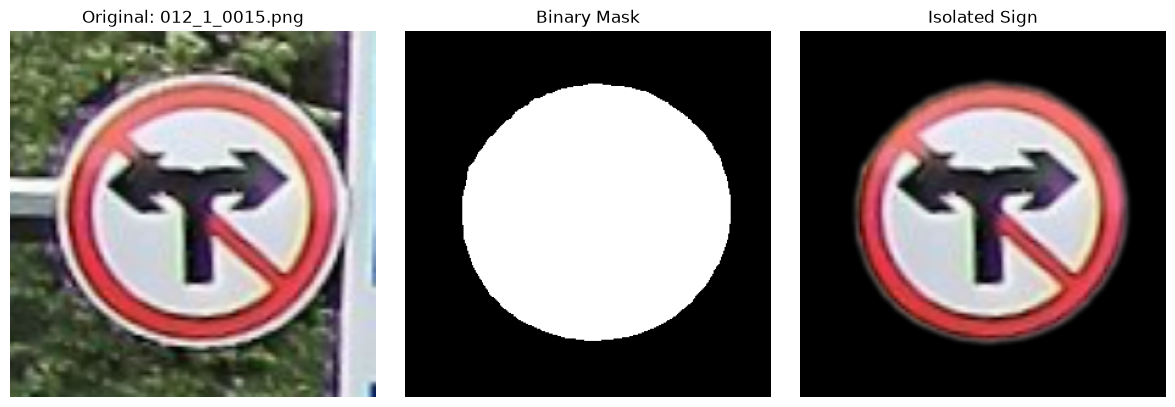

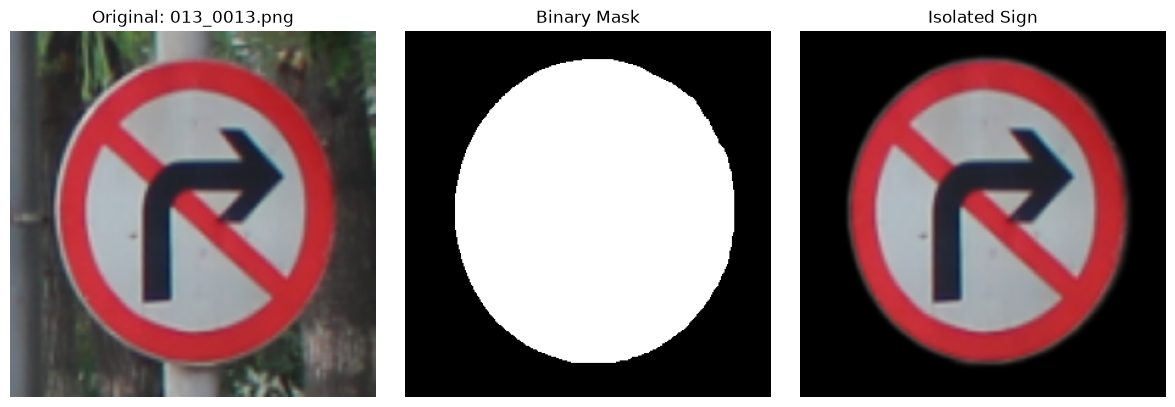

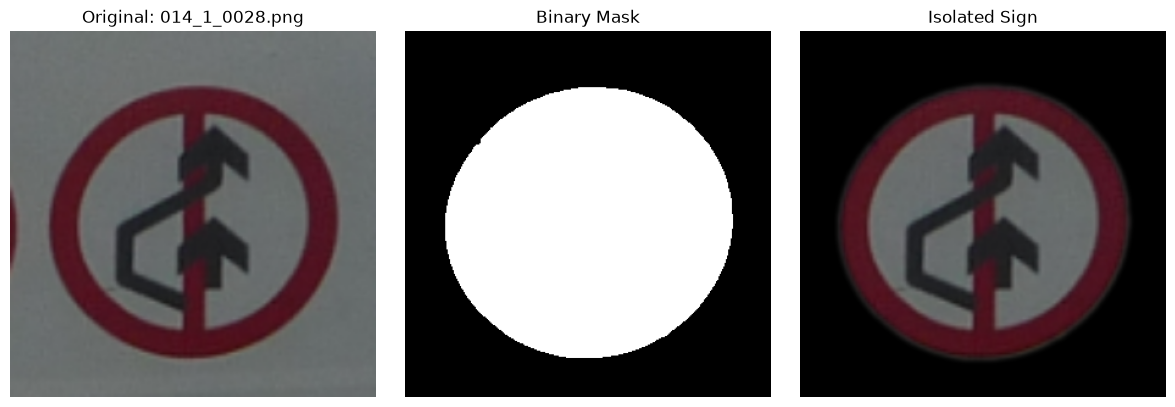

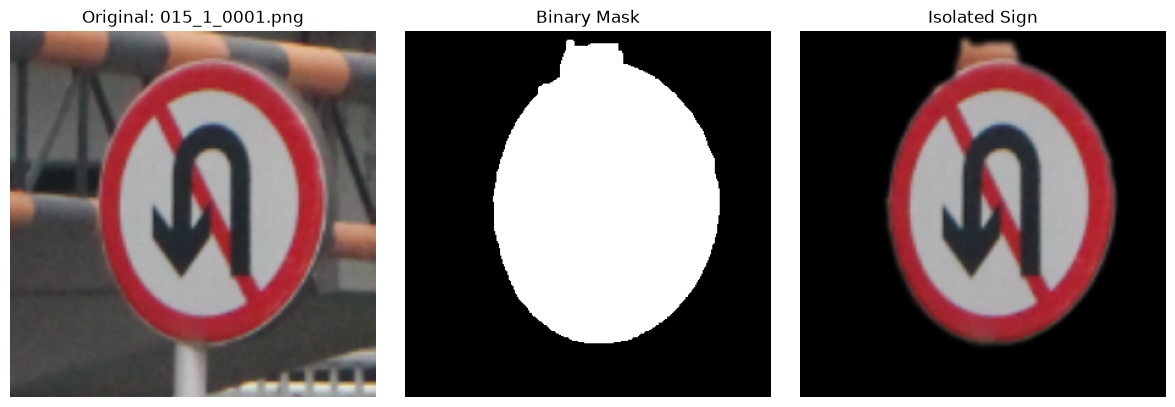

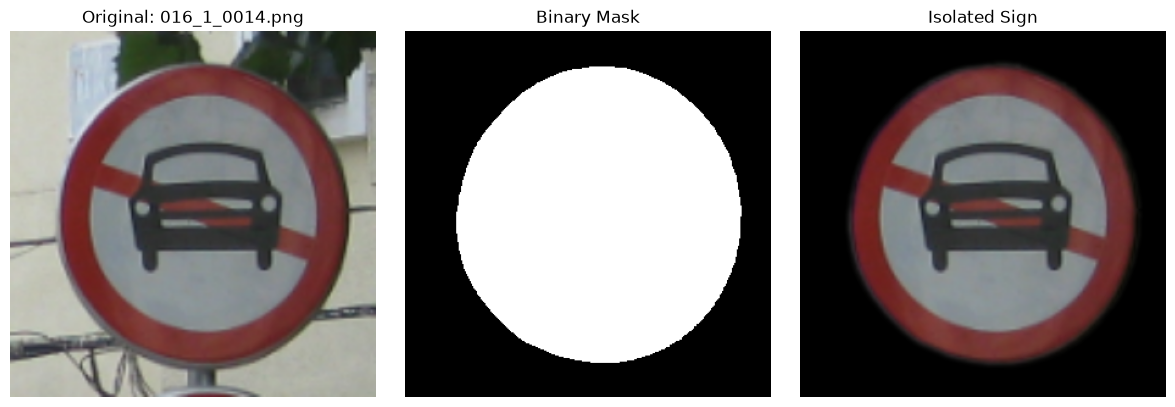

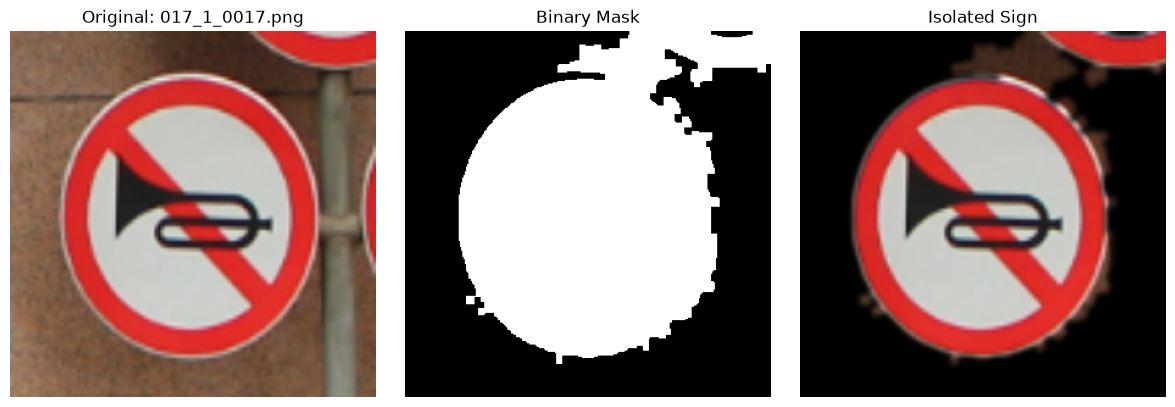

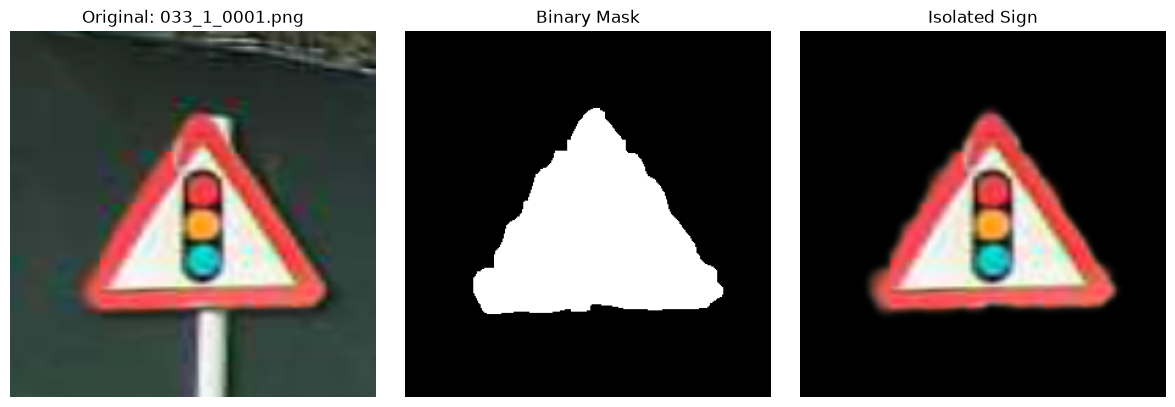

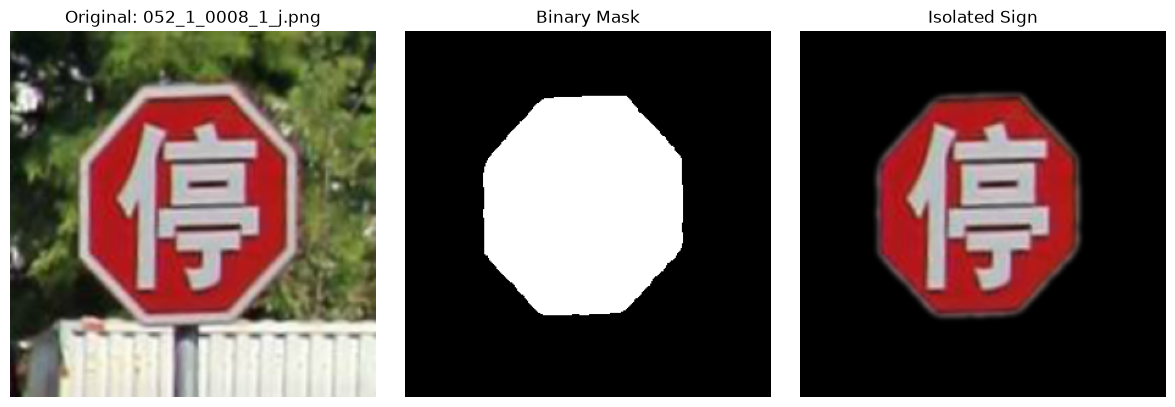

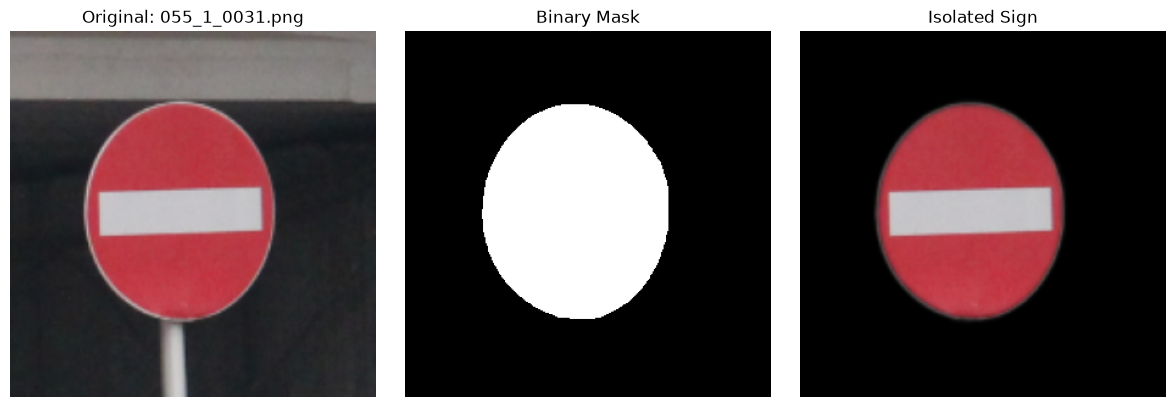

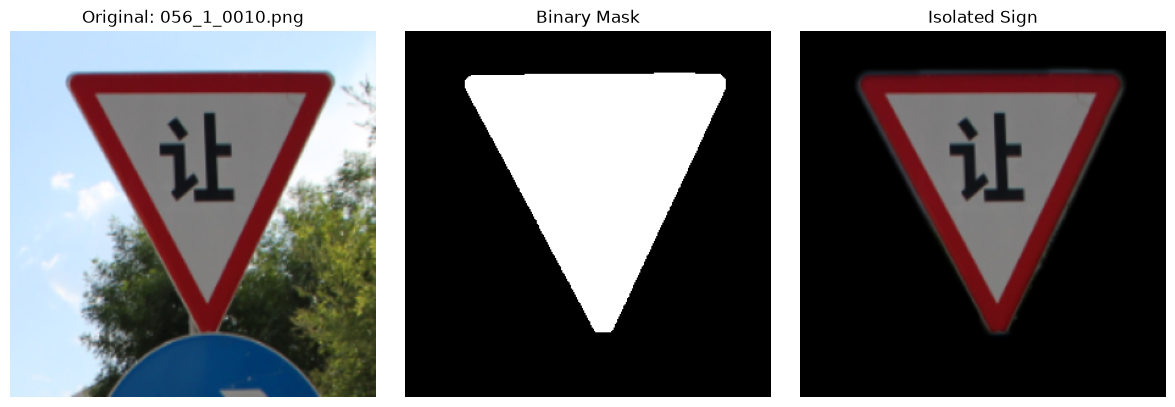

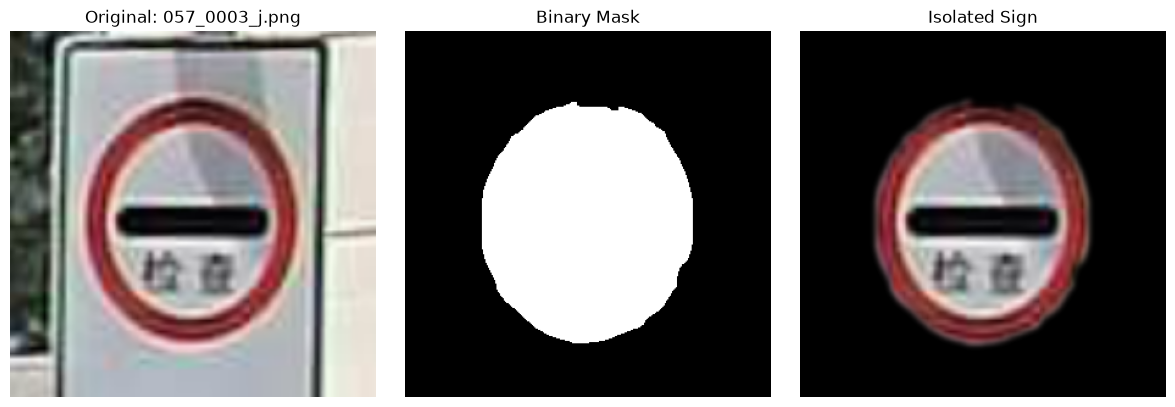

In [3]:
import math
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Instantiate the Segmenter
segmenter = SignSegmenter()

# 2. Define the Target Path (Points directly to your Red signs folder)
dataset_path = Path(
    r"C:\Users\jonat\OneDrive\Desktop\degree\y2s2\mini project\UCCC2513_Trimester_202506_P16_Group4_Traffic_Sign_Segmentation_and_Classification\Coding Environment\dataset\Demo\Inputs - Original\Red signs"
)

# 3. Load the Dataset
dataset = load_dataset(dataset_path)
print(f"Loaded {len(dataset)} images for processing.")

# 4. Display Results Loop
for path, original_rgb in dataset:
    resized_rgb = cv2.resize(original_rgb, (300, 300))

    # Perform segmentation
    extracted_roi, mask = segmenter.isolate_red(resized_rgb)

    # Plot original image, binary mask, and segmented sign side-by-side
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(resized_rgb)
    axes[0].set_title(f"Original: {path.name}")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Binary Mask")

    axes[2].imshow(extracted_roi)
    axes[2].set_title("Isolated Sign")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()